# Triage Prediction Pipeline - OOP Implementation

This notebook implements a complete triage prediction pipeline using Object-Oriented Programming principles.

## 1. Load Data

In [27]:
# Import necessary libraries and OOP modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")

# Import OOP modules
from modules.data_loader import load_data
from modules.preprocessing import NumericalPreprocessor, CategoricalPreprocessor, TextPreprocessor, FeatureBuilder, DataProcessorOOP
from modules.visualization import DataAnalysis, DataVisualizer
from modules.models import ModelTrainer
from modules.evaluation import ModelEvaluator, ModelExporter
from modules.config import SEED, TARGET, TEST_SIZE
from sklearn.model_selection import train_test_split

In [28]:
# Load data using OOP DataLoader
chief_complaint_data, patient_history_data, train_data, test_data, sample_submission_data = load_data()
print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

Train data shape: (80000, 67)
Test data shape: (20000, 64)


In [29]:
# Reload modules to get latest changes
import importlib
import modules.visualization
importlib.reload(modules.visualization)
from modules.visualization import DataAnalysis, DataVisualizer

# Reinitialize objects with reloaded modules
data_analysis = DataAnalysis(train_data)
data_visualizer = DataVisualizer()

In [30]:
# Reload preprocessing module
import importlib
import modules.preprocessing
importlib.reload(modules.preprocessing)
from modules.preprocessing import NumericalPreprocessor, CategoricalPreprocessor, TextPreprocessor, FeatureBuilder

In [31]:
# Set environment seed for reproducible results
def seeder(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seeder(SEED)

## 2. Data Analysis and Visualization

In [32]:
# Initialize DataAnalysis and DataVisualizer
data_analysis = DataAnalysis(train_data)
data_visualizer = DataVisualizer()

In [33]:
# Analyze missing values
missing_analysis = data_analysis.analyze_missing_values()
print("Missing values analysis:")
print(missing_analysis)

Missing values analysis:
                                        column  missing_count  \
systolic_bp                        systolic_bp           4146   
diastolic_bp                      diastolic_bp           4146   
mean_arterial_pressure  mean_arterial_pressure           4146   
pulse_pressure                  pulse_pressure           4146   
shock_index                        shock_index           4146   
respiratory_rate              respiratory_rate           3067   
temperature_c                    temperature_c            574   

                        missing_percentage  
systolic_bp                           5.18  
diastolic_bp                          5.18  
mean_arterial_pressure                5.18  
pulse_pressure                        5.18  
shock_index                           5.18  
respiratory_rate                      3.83  
temperature_c                         0.72  


Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\missing_values_heatmap.png


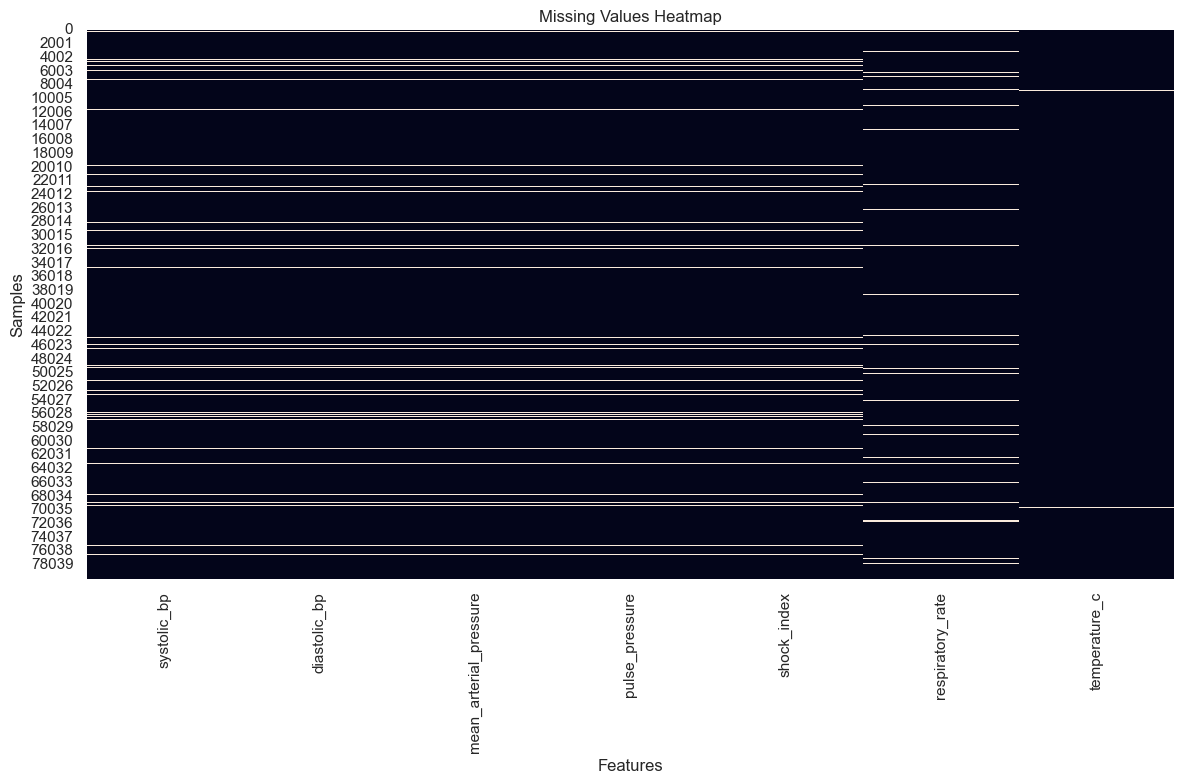


**Insight:** Missing values in groups (e.g., BP parameters) indicate that when blood pressure is missing, all related metrics are also missing. This suggests imputation strategies should consider these relationships.


In [34]:
# Plot missing values heatmap
data_visualizer.plot(plot_type="missing_heatmap", data=train_data, missing_analysis=missing_analysis)
print("\n**Insight:** Missing values in groups (e.g., BP parameters) indicate that when blood pressure is missing, all related metrics are also missing. This suggests imputation strategies should consider these relationships.")

Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\target_distribution.png


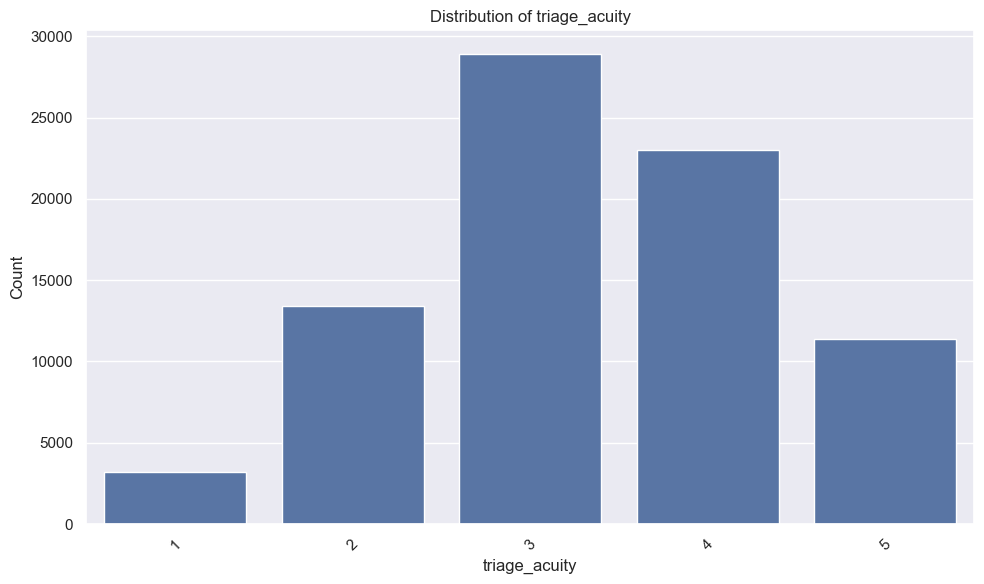


**Insight:** The target classes show imbalance with higher representation of less urgent cases. This justifies the use of SMOTE for oversampling to balance the classes during training.


In [35]:
# Plot target distribution
data_visualizer.plot(plot_type="target_distribution", data=train_data, target_col=TARGET)
print("\n**Insight:** The target classes show imbalance with higher representation of less urgent cases. This justifies the use of SMOTE for oversampling to balance the classes during training.")

In [36]:
# Analyze correlations
correlation_matrix = data_analysis.analyze_correlations(target_col=TARGET)
print("\nCorrelations with target:")
print(correlation_matrix)


Correlations with target:
                                triage_acuity
news2_score                         -0.814804
ed_los_hours                        -0.756714
respiratory_rate                    -0.652945
temperature_c                       -0.649193
shock_index                         -0.631830
pain_score                          -0.618834
heart_rate                          -0.567962
num_prior_ed_visits_12m             -0.564138
num_prior_admissions_12m            -0.311197
num_comorbidities                   -0.142150
comorbidity_count                   -0.142150
num_active_medications              -0.094220
hx_hyperthyroidism                  -0.053749
hx_liver_disease                    -0.052915
hx_coagulopathy                     -0.051430
hx_anxiety                          -0.051357
hx_immunosuppressed                 -0.050834
hx_asthma                           -0.050180
hx_diabetes_type1                   -0.049388
hx_hiv                              -0.048820
hx_epil

Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\correlation_heatmap.png


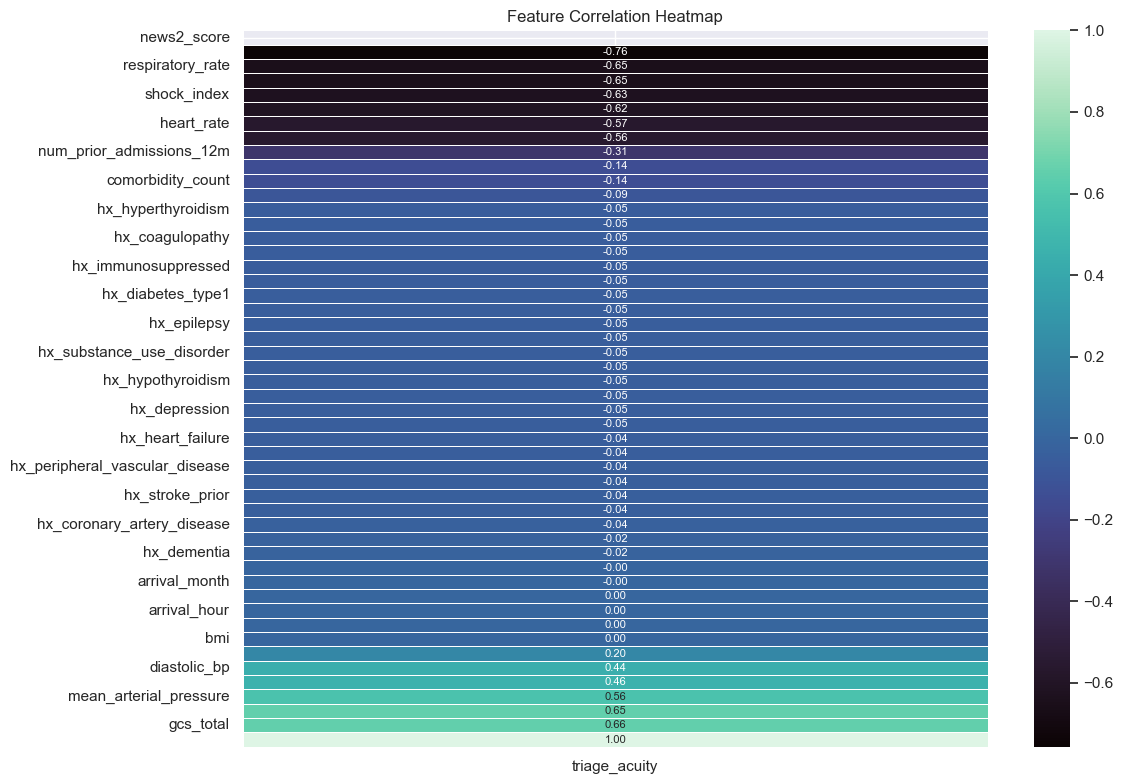


**Insight:** Features like 'news2_score' and 'shock_index' show strong correlations with acuity level, validating their importance in triage decisions.


In [37]:
# Plot correlation heatmap
data_visualizer.plot(plot_type="correlation_heatmap", correlation_matrix=correlation_matrix)
print("\n**Insight:** Features like 'news2_score' and 'shock_index' show strong correlations with acuity level, validating their importance in triage decisions.")

Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\numerical_distributions.png


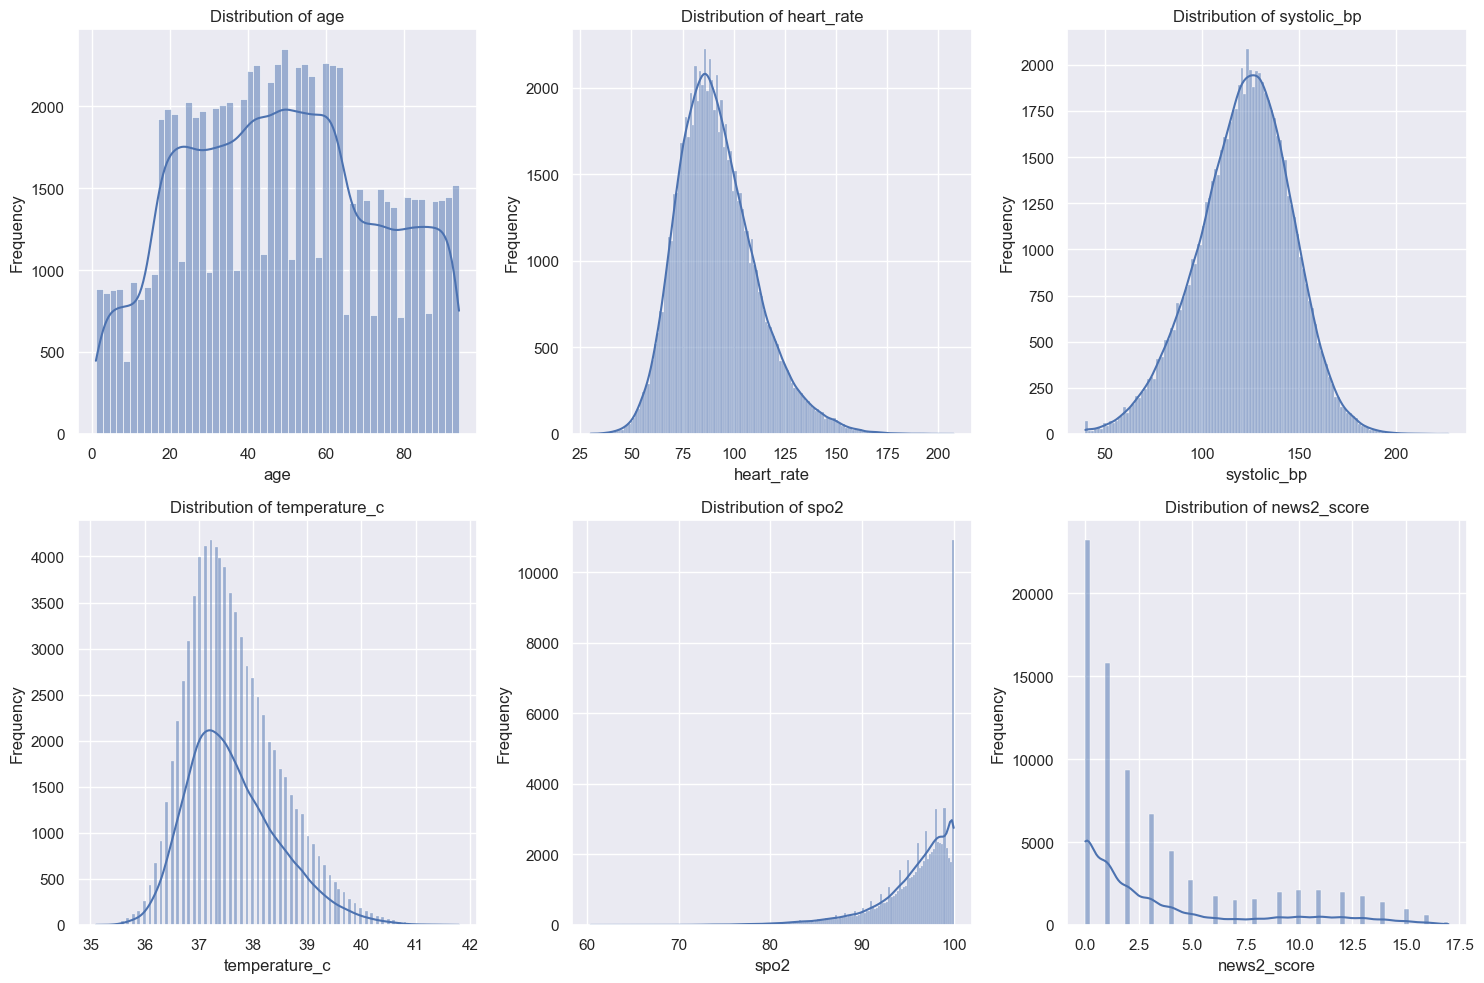


**Insight:** Numerical features show varying distributions. Features like 'news2_score' have right-skewed distributions typical of medical scoring systems, justifying the use of StandardScaler for normalization.


In [38]:
# Plot numerical distributions
key_numerical_cols = ['age', 'heart_rate', 'systolic_bp', 'temperature_c', 'spo2', 'news2_score']
data_visualizer.plot(plot_type="numerical_distributions", data=train_data, num_cols=key_numerical_cols)
print("\n**Insight:** Numerical features show varying distributions. Features like 'news2_score' have right-skewed distributions typical of medical scoring systems, justifying the use of StandardScaler for normalization.")

## 3. Data Preprocessing

In [39]:
# Initialize preprocessors
numerical_preprocessor = NumericalPreprocessor()
categorical_preprocessor = CategoricalPreprocessor()
text_preprocessor = TextPreprocessor(text_col='chief_complaint_raw')

# Create feature builder with all preprocessors
preprocessors = [numerical_preprocessor, categorical_preprocessor, text_preprocessor]
feature_builder = FeatureBuilder(preprocessors)

In [40]:
# Check unique values in y_train
print("Unique values in y_train:", np.unique(y_train))

Unique values in y_train: [0 1 2 3 4]


In [41]:
# Build features using OOP pipeline
X_train_features = feature_builder.build(X_train)
X_val_features = feature_builder.build(X_val)
X_test_features = feature_builder.build(X_test)

print(f"Training features shape: {X_train_features.shape}")
print(f"Validation features shape: {X_val_features.shape}")
print(f"Test features shape: {X_test_features.shape}")

Training features shape: (64000, 568)
Validation features shape: (16000, 568)
Test features shape: (20000, 568)


In [42]:
# Check unique values in y_train_processed
print("Unique values in y_train_processed:", np.unique(y_train_processed))

Unique values in y_train_processed: [0 1 2 3 4]


## 4. Machine Learning

In [43]:
# Initialize and train models using OOP ModelTrainer
model_trainer = ModelTrainer()
trained_models = model_trainer.train_models(X_train_processed, y_train_processed)
print("Trained models:", list(trained_models.keys()))

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Trained models: ['Logistic Regression', 'Random Forest', 'XGBoost']


## 5. Model Evaluation and Comparison

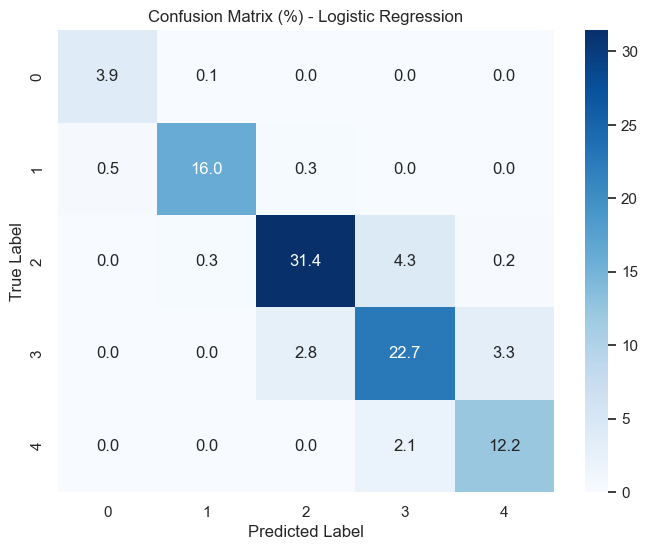

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       644
           1       0.98      0.95      0.96      2688
           2       0.91      0.87      0.89      5784
           3       0.78      0.79      0.78      4604
           4       0.78      0.85      0.81      2280

    accuracy                           0.86     16000
   macro avg       0.87      0.89      0.88     16000
weighted avg       0.86      0.86      0.86     16000



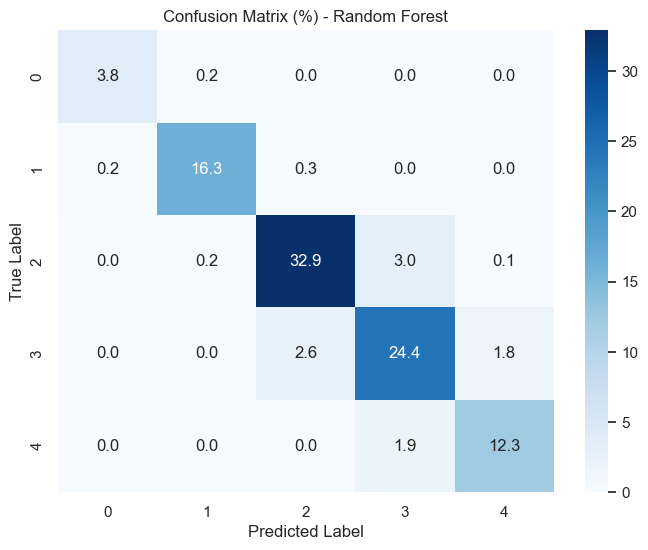

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       644
           1       0.98      0.97      0.97      2688
           2       0.92      0.91      0.91      5784
           3       0.83      0.85      0.84      4604
           4       0.87      0.86      0.87      2280

    accuracy                           0.90     16000
   macro avg       0.91      0.91      0.91     16000
weighted avg       0.90      0.90      0.90     16000



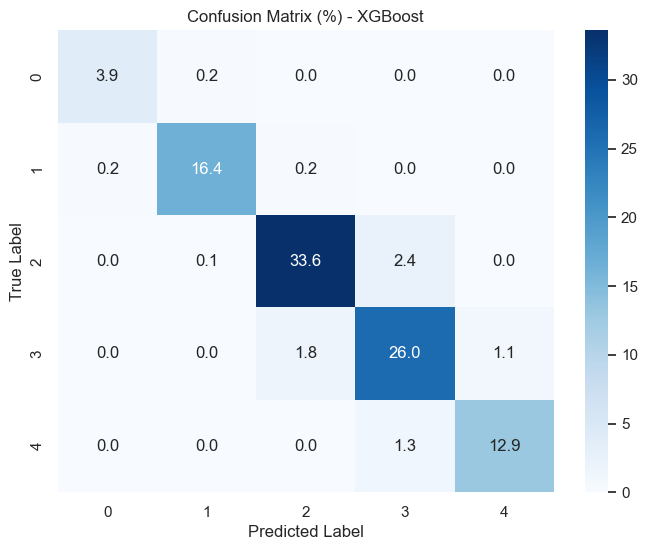

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       644
           1       0.98      0.98      0.98      2688
           2       0.94      0.93      0.94      5784
           3       0.88      0.90      0.89      4604
           4       0.92      0.91      0.91      2280

    accuracy                           0.93     16000
   macro avg       0.94      0.94      0.94     16000
weighted avg       0.93      0.93      0.93     16000


Model Evaluation Results:
                 Model  Accuracy  Precision    Recall  F1-Score ROC-AUC
0  Logistic Regression  0.861938   0.864429  0.861938  0.862670    None
1        Random Forest  0.897312   0.897801  0.897312  0.897524    None
2              XGBoost  0.927937   0.928516  0.927937  0.928141    None


In [44]:
# Evaluate models using OOP ModelEvaluator
model_evaluator = ModelEvaluator()
evaluation_results = model_evaluator.evaluate_models(trained_models, X_val_processed, y_val)
print("\nModel Evaluation Results:")
print(evaluation_results)

## 6. Export Best Model

In [45]:
# Export best model using OOP ModelExporter
model_exporter = ModelExporter()
exported_path = model_exporter.export_best_model(trained_models, evaluation_results, metric='F1-Score')
print(f"\nBest model exported to: {exported_path}")

✅ Exported best model 'XGBoost' (Score: 0.9281) to output\best_model_ranked.pkl

Best model exported to: output\best_model_ranked.pkl
